In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project root
ROOT = Path.cwd().parent

TRANSACTION_PATH = ROOT / "data" / "raw" / "train_transaction.csv"
IDENTITY_PATH = ROOT / "data" / "raw" / "train_identity.csv"

print("Transaction file:", TRANSACTION_PATH)
print("Identity file:", IDENTITY_PATH)

print("Transaction exists:", TRANSACTION_PATH.exists())
print("Identity exists:", IDENTITY_PATH.exists())

Transaction file: c:\Users\Gaurav Sehgal\OneDrive\Desktop\financial_fraud_detection_agent\data\raw\train_transaction.csv
Identity file: c:\Users\Gaurav Sehgal\OneDrive\Desktop\financial_fraud_detection_agent\data\raw\train_identity.csv
Transaction exists: True
Identity exists: True


In [3]:
transactions = pd.read_csv(TRANSACTION_PATH)
identity = pd.read_csv(IDENTITY_PATH)

print("Transaction shape:", transactions.shape)
print("Identity shape:", identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [4]:
transactions["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [5]:
fraud_rate = transactions["isFraud"].mean() * 100

print(f"Fraud rate: {fraud_rate:.2f}%")

Fraud rate: 3.50%


In [6]:
missing = (
    transactions.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing.head(30)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D8       87.312290
D9       87.312290
V162     86.123717
V142     86.123717
V146     86.123717
V147     86.123717
V141     86.123717
V138     86.123717
V163     86.123717
V161     86.123717
V154     86.123717
V153     86.123717
V158     86.123717
V157     86.123717
V139     86.123717
V148     86.123717
V149     86.123717
V140     86.123717
V156     86.123717
V155     86.123717
V151     86.122701
V159     86.122701
V165     86.122701
V164     86.122701
dtype: float64

In [7]:
print(
    "Transaction IDs in transaction table:",
    transactions["TransactionID"].nunique()
)

print(
    "Transaction IDs in identity table:",
    identity["TransactionID"].nunique()
)

print(
    "Identity IDs also present in transactions:",
    identity["TransactionID"].isin(
        transactions["TransactionID"]
    ).mean() * 100
)

Transaction IDs in transaction table: 590540
Transaction IDs in identity table: 144233
Identity IDs also present in transactions: 100.0


In [8]:
merged = transactions.merge(
    identity,
    on="TransactionID",
    how="left"
)

print("Merged shape:", merged.shape)

Merged shape: (590540, 434)


In [9]:
transactions.groupby("isFraud")["TransactionAmt"].describe()

transactions.groupby("isFraud")["TransactionAmt"].mean()

transactions.groupby("isFraud")["TransactionAmt"].median()

isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

In [10]:
transactions.groupby("isFraud")["TransactionDT"].describe()


transactions.sort_values("TransactionDT")[
    ["TransactionID", "TransactionDT", "isFraud"]
].head()



transactions.sort_values("TransactionDT")[
    ["TransactionID", "TransactionDT", "isFraud"]
].tail()

,TransactionID,TransactionDT,isFraud
590535,3577535,15811047,0
590536,3577536,15811049,0
590537,3577537,15811079,0
590538,3577538,15811088,0
590539,3577539,15811131,0


In [11]:
print("TransactionDT min:", transactions["TransactionDT"].min())
print("TransactionDT max:", transactions["TransactionDT"].max())


print(
    transactions.groupby("isFraud")["TransactionDT"]
    .agg(["min", "max", "mean", "median"])
)


print(
    transactions.groupby("isFraud")["TransactionDT"]
    .agg(["min", "max", "mean", "median"])
)

TransactionDT min: 86400
TransactionDT max: 15811131
           min       max          mean     median
isFraud                                          
0        86400  15811131  7.360791e+06  7271678.0
1        89760  15810876  7.690033e+06  7575230.0
           min       max          mean     median
isFraud                                          
0        86400  15811131  7.360791e+06  7271678.0
1        89760  15810876  7.690033e+06  7575230.0


In [12]:
merged_check = transactions[["TransactionID", "isFraud"]].merge(
    identity[["TransactionID"]],
    on="TransactionID",
    how="left",
    indicator=True
)

merged_check["has_identity"] = (
    merged_check["_merge"] == "both"
).astype(int)

print(
    merged_check.groupby("isFraud")["has_identity"]
    .mean()
)

isFraud
0    0.233235
1    0.547742
Name: has_identity, dtype: float64


In [13]:
import sys
from pathlib import Path

# Add the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.features.feature_engineering import add_basic_features

features_df = add_basic_features(
    transactions,
    identity
)

print(features_df.shape)

(590540, 401)


In [14]:
features_df[
    [
        "TransactionID",
        "TransactionAmt",
        "TransactionAmt_log",
        "transaction_hour",
        "transaction_day",
        "has_identity",
        "missing_card_info",
        "missing_address",
        "missing_value_count",
        "isFraud"
    ]
].head()

,TransactionID,TransactionAmt,TransactionAmt_log,transaction_hour,transaction_day,has_identity,missing_card_info,missing_address,missing_value_count,isFraud
0,2987000,68.5,4.241327,0,1,0,1,0,194,0
1,2987001,29.0,3.401197,0,1,0,0,0,190,0
2,2987002,59.0,4.094345,0,1,0,0,0,171,0
3,2987003,50.0,3.931826,0,1,0,0,0,187,0
4,2987004,50.0,3.931826,0,1,1,0,0,120,0


In [15]:
import sys
from pathlib import Path

# Add the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))


from src.data.split import time_based_split

train_df, validation_df, test_df = time_based_split(
    features_df
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (413378, 401)
Validation: (88581, 401)
Test: (88581, 401)


In [16]:
print("TRAIN")
print(train_df["TransactionDT"].min())
print(train_df["TransactionDT"].max())

print("\nVALIDATION")
print(validation_df["TransactionDT"].min())
print(validation_df["TransactionDT"].max())

print("\nTEST")
print(test_df["TransactionDT"].min())
print(test_df["TransactionDT"].max())

TRAIN
86400
10437996

VALIDATION
10438003
13151840

TEST
13151880
15811131


In [17]:
for name, df in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    fraud_count = df["isFraud"].sum()
    fraud_rate = df["isFraud"].mean() * 100

    print(
        f"{name}: "
        f"{len(df):,} transactions | "
        f"{fraud_count:,} fraud | "
        f"{fraud_rate:.2f}% fraud"
    )

Train: 413,378 transactions | 14,538 fraud | 3.52% fraud
Validation: 88,581 transactions | 3,042 fraud | 3.43% fraud
Test: 88,581 transactions | 3,083 fraud | 3.48% fraud


In [18]:
import sys
import importlib
from pathlib import Path

# Add the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import and reload the module to get the latest version
import src.features.behavioural_features as bf_module
importlib.reload(bf_module)

from src.features.behavioural_features import (
    add_card_behavior_features,
    add_card_velocity_features,
    add_device_profile_features,
    
)

# Create behavioral features
behavior_df = train_df.copy()
behavior_df = add_card_behavior_features(behavior_df)
behavior_df = add_card_velocity_features(behavior_df)

print(behavior_df.shape)

(413378, 407)


In [19]:
behavior_df[
    [
        "TransactionID",
        "card1",
        "TransactionDT",
        "TransactionAmt",
        "card_transaction_count",
        "card_avg_amount",
        "amount_vs_card_avg",
        "new_card",
        "isFraud"
    ]
].head(20)

,TransactionID,card1,TransactionDT,TransactionAmt,card_transaction_count,card_avg_amount,amount_vs_card_avg,new_card,isFraud
0,3230924,1000,5787419,23.443,0,NaN,NaN,1,0
1,3023634,1001,916268,183.000,0,NaN,NaN,1,0
2,3151336,1001,3504180,29.000,1,183.000000,0.158470,0,0
3,3210739,1001,5270458,27.000,2,106.000000,0.254717,0,0
4,3020767,1004,842821,150.000,0,NaN,NaN,1,0
5,3028973,1004,1022173,30.000,1,150.000000,0.200000,0,0
6,3386444,1004,10082484,50.000,2,90.000000,0.555556,0,0
7,3038871,1005,1212802,50.000,0,NaN,NaN,1,0
8,3095681,1006,2145214,150.000,0,NaN,NaN,1,0
9,3234681,1006,5883179,150.000,1,150.000000,1.000000,0,0


In [20]:
print(
    behavior_df["card_txn_count_1h"].describe()
)

count    413378.000000
mean          1.358918
std           3.294610
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          68.000000
Name: card_txn_count_1h, dtype: float64


In [21]:
print(
    behavior_df[
        ["card1", "TransactionDT", "card_txn_count_1h"]
    ].head(20)
)

    card1  TransactionDT  card_txn_count_1h
0    1000        5787419                  0
1    1001         916268                  0
2    1001        3504180                  0
3    1001        5270458                  0
4    1004         842821                  0
5    1004        1022173                  0
6    1004       10082484                  0
7    1005        1212802                  0
8    1006        2145214                  0
9    1006        5883179                  0
10   1007         850730                  0
11   1007        5651177                  0
12   1008        5845013                  0
13   1008        7241294                  0
14   1009         354228                  0
15   1009         926293                  0
16   1009        1222657                  0
17   1009        1539008                  0
18   1009        1786013                  0
19   1010        9826142                  0


In [22]:
print(behavior_df["card_txn_count_1h"].describe())

print(
    "Non-zero:",
    (behavior_df["card_txn_count_1h"] > 0).sum()
)

print(
    "Maximum:",
    behavior_df["card_txn_count_1h"].max()
)

count    413378.000000
mean          1.358918
std           3.294610
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          68.000000
Name: card_txn_count_1h, dtype: float64
Non-zero: 176933
Maximum: 68


In [23]:
print(
    behavior_df[
        [
            "card_txn_count_1h",
            "card_txn_count_24h"
        ]
    ].describe()
)

       card_txn_count_1h  card_txn_count_24h
count      413378.000000       413378.000000
mean            1.358918           19.078761
std             3.294610           42.090811
min             0.000000            0.000000
25%             0.000000            1.000000
50%             0.000000            5.000000
75%             1.000000           20.000000
max            68.000000          654.000000


In [24]:
print(
    (
        behavior_df["card_txn_count_24h"]
        >= behavior_df["card_txn_count_1h"]
    ).all()
)

True


In [25]:
identity["DeviceInfo"].head()

0    SAMSUNG SM-G892A Build/NRD90M
1                       iOS Device
2                          Windows
3                              NaN
4                            MacOS
Name: DeviceInfo, dtype: str

In [26]:
features_df[
    [
        "TransactionID",
        "TransactionAmt",
        "TransactionAmt_log",
        "transaction_hour",
        "transaction_day",
        "has_identity",
        "missing_card_info",
        "missing_address",
        "missing_value_count",
        "isFraud"
    ]
].head()

,TransactionID,TransactionAmt,TransactionAmt_log,transaction_hour,transaction_day,has_identity,missing_card_info,missing_address,missing_value_count,isFraud
0,2987000,68.5,4.241327,0,1,0,1,0,194,0
1,2987001,29.0,3.401197,0,1,0,0,0,190,0
2,2987002,59.0,4.094345,0,1,0,0,0,171,0
3,2987003,50.0,3.931826,0,1,0,0,0,187,0
4,2987004,50.0,3.931826,0,1,1,0,0,120,0


In [27]:
identity["DeviceInfo"].head()

0    SAMSUNG SM-G892A Build/NRD90M
1                       iOS Device
2                          Windows
3                              NaN
4                            MacOS
Name: DeviceInfo, dtype: str

In [28]:
print(
    "Unique devices:",
    identity["DeviceInfo"].nunique()
)

print(
    "Missing devices:",
    identity["DeviceInfo"].isna().mean() * 100
)

Unique devices: 1786
Missing devices: 17.726179168428864


In [29]:
device_data = identity[
    [
        "TransactionID",
        "DeviceInfo"
    ]
].copy()


behavior_df = behavior_df.merge(
    device_data,
    on="TransactionID",
    how="left"
)

In [30]:
behavior_df[
    [
        "TransactionID",
        "card1",
        "DeviceInfo"
    ]
].head(20)

,TransactionID,card1,DeviceInfo
0,3230924,1000,F3213 Build/36.0.A.2.146
1,3023634,1001,NaN
2,3151336,1001,NaN
3,3210739,1001,NaN
4,3020767,1004,MacOS
5,3028973,1004,Trident/7.0
6,3386444,1004,iOS Device
7,3038871,1005,Trident/7.0
8,3095681,1006,iOS Device
9,3234681,1006,rv:11.0


In [31]:
print(identity["DeviceInfo"].head())

print(
    "Unique devices:",
    identity["DeviceInfo"].nunique()
)

print(
    "Missing devices:",
    identity["DeviceInfo"].isna().mean() * 100
)

0    SAMSUNG SM-G892A Build/NRD90M
1                       iOS Device
2                          Windows
3                              NaN
4                            MacOS
Name: DeviceInfo, dtype: str
Unique devices: 1786
Missing devices: 17.726179168428864


In [32]:
device_data = identity[
    [
        "TransactionID",
        "DeviceInfo"
    ]
].copy()

In [33]:
behavior_df = behavior_df.drop(
    columns=["DeviceInfo"],
    errors="ignore"
)

behavior_df = behavior_df.merge(
    device_data,
    on="TransactionID",
    how="left"
)

In [34]:
behavior_df = add_device_profile_features(
    behavior_df
)

In [35]:
behavior_df[
    [
        "TransactionID",
        "card1",
        "DeviceInfo",
        "has_device_info",
        "device_profile_count",
        "device_profile_unique_cards",
        "new_device_profile",
        "isFraud"
    ]
].head(30)

,TransactionID,card1,DeviceInfo,has_device_info,device_profile_count,device_profile_unique_cards,new_device_profile,isFraud
0,3105398,14128,0PAJ5,1,0,0,1,0
1,3091537,11942,0PJA2,1,0,0,1,0
2,3087675,10027,0PM92,1,0,0,1,0
3,3094705,6174,0PM92,1,1,1,0,0
4,3306333,3702,0PM92,1,2,2,0,1
5,3306337,1976,0PM92,1,3,3,0,1
6,3142945,11195,1016S,1,0,0,1,0
7,3021070,3682,2PQ93,1,0,0,1,0
8,3023129,15497,2PS64 Build/NRD90M,1,0,0,1,0
9,3059407,14290,2PS64 Build/NRD90M,1,1,1,0,0


In [36]:
print(
    behavior_df[
        [
            "device_profile_count",
            "device_profile_unique_cards"
        ]
    ].describe()
)

       device_profile_count  device_profile_unique_cards
count         413378.000000                413378.000000
mean            2114.927763                   366.309013
std             6298.501821                   948.069941
min                0.000000                     0.000000
25%                0.000000                     0.000000
50%                0.000000                     0.000000
75%                0.000000                     0.000000
max            36667.000000                  4348.000000


In [37]:
print(
    behavior_df.groupby("isFraud")[
        [
            "has_device_info",
            "device_profile_count",
            "device_profile_unique_cards",
            "new_device_profile"
        ]
    ].mean()
)

         has_device_info  device_profile_count  device_profile_unique_cards  \
isFraud                                                                       
0               0.213522           2030.255471                   354.671104   
1               0.426537           4437.853694                   685.587013   

         new_device_profile  
isFraud                      
0                  0.003658  
1                  0.005984  


In [38]:
import sys
import importlib
from pathlib import Path

# Add the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import and reload the module to get the latest version
import src.features.behavioural_features as bf_module
importlib.reload(bf_module)
from src.features.behavioural_features import add_card_device_features

In [39]:
behavior_df = add_card_device_features(
    behavior_df
)

In [40]:
behavior_df[
    [
        "TransactionID",
        "card1",
        "DeviceInfo",
        "card_device_transaction_count",
        "card_device_seen_before",
        "isFraud"
    ]
].head(30)

,TransactionID,card1,DeviceInfo,card_device_transaction_count,card_device_seen_before,isFraud
0,3105398,14128,0PAJ5,0,0,0
1,3091537,11942,0PJA2,0,0,0
2,3306337,1976,0PM92,0,0,1
3,3306333,3702,0PM92,0,0,1
4,3094705,6174,0PM92,0,0,0
5,3087675,10027,0PM92,0,0,0
6,3142945,11195,1016S,0,0,0
7,3021070,3682,2PQ93,0,0,0
8,3103301,4029,2PS64 Build/NRD90M,0,0,0
9,3064774,4577,2PS64 Build/NRD90M,0,0,0


In [41]:
print(
    behavior_df.groupby("isFraud")[
        [
            "card_device_transaction_count",
            "card_device_seen_before"
        ]
    ].mean()
)

         card_device_transaction_count  card_device_seen_before
isFraud                                                        
0                            17.727710                 0.162541
1                            32.159375                 0.329413


In [42]:
import sys
import importlib
from pathlib import Path

# Add the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
# Import and reload the module to get the latest version
import src.models.features as features_module
importlib.reload(features_module)

# Define INITIAL_FEATURES based on available columns
# INITIAL_FEATURES = [col for col in behavior_df.columns if col not in ['TransactionID', 'isFraud']]

from src.models.features import INITIAL_FEATURES

X = behavior_df[INITIAL_FEATURES].copy()
y = behavior_df["isFraud"].copy()

In [43]:
print(
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

amount_vs_card_avg                12242
card_avg_amount                   12242
transaction_hour                      0
TransactionAmt_log                    0
TransactionAmt                        0
has_identity                          0
transaction_day                       0
missing_card_info                     0
missing_address                       0
card_transaction_count                0
missing_value_count                   0
new_card                              0
card_txn_count_1h                     0
card_txn_count_24h                    0
has_device_info                       0
device_profile_count                  0
device_profile_unique_cards           0
new_device_profile                    0
card_device_transaction_count         0
card_device_seen_before               0
device_unique_cards_historical        0
dtype: int64


In [44]:
behavior_df = behavior_df.sort_values(
    "TransactionDT"
).reset_index(drop=True)

X = behavior_df[INITIAL_FEATURES].copy()
y = behavior_df["isFraud"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

X shape: (413378, 21)
y shape: (413378,)

Missing values:
amount_vs_card_avg                12242
card_avg_amount                   12242
transaction_hour                      0
TransactionAmt_log                    0
TransactionAmt                        0
has_identity                          0
transaction_day                       0
missing_card_info                     0
missing_address                       0
card_transaction_count                0
missing_value_count                   0
new_card                              0
card_txn_count_1h                     0
card_txn_count_24h                    0
has_device_info                       0
device_profile_count                  0
device_profile_unique_cards           0
new_device_profile                    0
card_device_transaction_count         0
card_device_seen_before               0
device_unique_cards_historical        0
dtype: int64


In [45]:
missing_features = [
    feature
    for feature in INITIAL_FEATURES
    if feature not in behavior_df.columns
]

print("Missing feature columns:")
print(missing_features)

Missing feature columns:
[]


In [46]:
print(
    behavior_df[
        INITIAL_FEATURES
    ].shape
)

(413378, 21)


In [47]:
print("Number of features:", len(INITIAL_FEATURES))

print("\nFeatures:")
print(INITIAL_FEATURES)

print("\nMissing feature columns:")
print([
    f for f in INITIAL_FEATURES
    if f not in behavior_df.columns
])

Number of features: 21

Features:
['TransactionAmt', 'TransactionAmt_log', 'transaction_hour', 'transaction_day', 'has_identity', 'missing_card_info', 'missing_address', 'missing_value_count', 'card_transaction_count', 'card_avg_amount', 'amount_vs_card_avg', 'new_card', 'card_txn_count_1h', 'card_txn_count_24h', 'has_device_info', 'device_profile_count', 'device_profile_unique_cards', 'new_device_profile', 'card_device_transaction_count', 'card_device_seen_before', 'device_unique_cards_historical']

Missing feature columns:
[]


In [48]:


from src.models.features import INITIAL_FEATURES

X_train = behavior_df[INITIAL_FEATURES].copy()
y_train = behavior_df["isFraud"].copy()

print(X_train.shape)
print(y_train.shape)

(413378, 21)
(413378,)


In [49]:
from src.models.baseline import build_logistic_baseline

baseline_model = build_logistic_baseline()

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [50]:
from src.features.build_features import build_historical_features

In [51]:
# train_val_raw = pd.concat(
#     [
#         train_df,
#         validation_df
#     ],
#     ignore_index=True
# )

In [52]:
from src.features.historical_features import prepare_history

In [53]:
history_train = prepare_history(
    train_df,
    identity
)

history_validation = prepare_history(
    validation_df,
    identity
)

print("Train history:", history_train.shape)
print("Validation history:", history_validation.shape)

Train history: (413378, 5)
Validation history: (88581, 5)


In [54]:
history_train_val = pd.concat(
    [
        history_train,
        history_validation
    ],
    ignore_index=True
)

print("Combined history:", history_train_val.shape)

Combined history: (501959, 5)


In [55]:
from src.features.behavioural_features import (
    add_card_behavior_features,
    add_card_velocity_features,
    add_device_profile_features,
    add_card_device_features
)

In [56]:
history_features = add_card_behavior_features(
    history_train_val
)

history_features = add_card_velocity_features(
    history_features
)

history_features = add_device_profile_features(
    history_features
)

history_features = add_card_device_features(
    history_features
)

In [57]:
history_features = (
    history_features
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

In [58]:
validation_start = validation_df["TransactionDT"].min()

validation_behavior = history_features[
    history_features["TransactionDT"] >= validation_start
].copy()

In [59]:
print(
    "Validation behavioral features:",
    validation_behavior.shape
)

Validation behavioral features: (88581, 18)


In [60]:
from src.features.feature_engineering import add_basic_features

validation_basic = add_basic_features(
    validation_df,
    identity
)

In [61]:
validation_basic

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V337,V338,V339,has_identity,TransactionAmt_log,transaction_hour,transaction_day,missing_card_info,missing_address,missing_value_count
413378,3400378,0,10438003,49.00,W,7239,452.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,0,3.912023,19,120,0,0,170
413379,3400379,1,10438017,1265.50,W,18227,583.0,150.0,visa,226.0,...,NaN,NaN,NaN,0,7.144012,19,120,0,0,187
413380,3400380,0,10438043,50.00,H,11919,170.0,150.0,mastercard,224.0,...,0.0,0.0,0.0,1,3.931826,19,120,0,0,119
413381,3400381,0,10438052,161.00,W,2377,203.0,150.0,visa,166.0,...,NaN,NaN,NaN,0,5.087596,19,120,0,0,171
413382,3400382,0,10438065,88.00,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,0,4.488636,19,120,0,0,168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501954,3488954,0,13151575,29.00,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,0,3.401197,5,152,0,0,170
501955,3488955,0,13151580,312.95,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,0,5.749234,5,152,0,0,174
501956,3488956,0,13151717,774.00,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,0,6.652863,5,152,0,0,172
501957,3488957,0,13151720,226.00,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,0,5.424950,5,152,0,0,192


In [62]:
device_data = identity[
    [
        "TransactionID",
        "DeviceInfo"
    ]
].copy()

validation_basic = validation_basic.merge(
    device_data,
    on="TransactionID",
    how="left"
)

In [63]:
behavior_columns = [
    "TransactionID",
    "card_transaction_count",
    "card_avg_amount",
    "amount_vs_card_avg",
    "new_card",
    "card_txn_count_1h",
    "card_txn_count_24h",
    "has_device_info",
    "device_profile_count",
    "device_profile_unique_cards",
    "new_device_profile",
    "card_device_transaction_count",
    "card_device_seen_before",
    "device_unique_cards_historical",
]

In [64]:
validation_features = validation_basic.merge(
    validation_behavior[behavior_columns],
    on="TransactionID",
    how="left"
)

In [65]:
print(
    "Validation features:",
    validation_features.shape
)

Validation features: (88581, 415)


In [66]:
from src.models.features import INITIAL_FEATURES

X_val = validation_features[
    INITIAL_FEATURES
].copy()

y_val = validation_features[
    "isFraud"
].copy()

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_val: (88581, 21)
y_val: (88581,)


In [67]:
print(
    X_val.isna()
    .sum()
    .sort_values(ascending=False)
)

amount_vs_card_avg                675
card_avg_amount                   675
transaction_hour                    0
TransactionAmt_log                  0
TransactionAmt                      0
has_identity                        0
transaction_day                     0
missing_card_info                   0
missing_address                     0
card_transaction_count              0
missing_value_count                 0
new_card                            0
card_txn_count_1h                   0
card_txn_count_24h                  0
has_device_info                     0
device_profile_count                0
device_profile_unique_cards         0
new_device_profile                  0
card_device_transaction_count       0
card_device_seen_before             0
device_unique_cards_historical      0
dtype: int64


In [68]:
y_val_prob = baseline_model.predict_proba(
    X_val
)[:, 1]

In [69]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

print("PR-AUC :", pr_auc)
print("ROC-AUC:", roc_auc)



PR-AUC : 0.09731628996415465
ROC-AUC: 0.7401501976648535


In [70]:
threshold = 0.5

y_val_pred = (
    y_val_prob >= threshold
).astype(int)

In [71]:
print(
    "Precision:",
    precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

Precision: 0.07425924564370266
Recall: 0.6640368178829718
F1: 0.13358021425737338

Confusion Matrix:
[[60357 25182]
 [ 1022  2020]]


In [72]:
from src.models.xgboost_model import build_xgboost_model

xgb_model = build_xgboost_model(y_train)

xgb_model.fit(
    X_train,
    y_train,
    verbose=True
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [73]:
y_val_prob_xgb = xgb_model.predict_proba(
    X_val
)[:, 1]

In [74]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pr_auc_xgb = average_precision_score(
    y_val,
    y_val_prob_xgb
)

roc_auc_xgb = roc_auc_score(
    y_val,
    y_val_prob_xgb
)

print("XGBoost PR-AUC :", pr_auc_xgb)
print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost PR-AUC : 0.20263825931359922
XGBoost ROC-AUC: 0.7864765082221897


In [75]:
y_val_pred_xgb = (
    y_val_prob_xgb >= 0.5
).astype(int)

print(
    "Precision:",
    precision_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_val,
        y_val_pred_xgb
    )
)


Precision: 0.13731973913842196
Recall: 0.49145299145299143
F1: 0.21466006174169
[[76147  9392]
 [ 1547  1495]]


In [76]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.05):

    predictions = (
        y_val_prob_xgb >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print(threshold_df)

    threshold  precision    recall        f1
0        0.05   0.037191  0.990138  0.071689
1        0.10   0.042892  0.958580  0.082110
2        0.15   0.049732  0.910585  0.094312
3        0.20   0.057292  0.857331  0.107407
4        0.25   0.065878  0.796187  0.121687
5        0.30   0.075682  0.726496  0.137084
6        0.35   0.087776  0.665680  0.155101
7        0.40   0.102924  0.612097  0.176217
8        0.45   0.118542  0.548323  0.194940
9        0.50   0.137320  0.491453  0.214660
10       0.55   0.158853  0.438856  0.233269
11       0.60   0.182655  0.391190  0.249032
12       0.65   0.210685  0.343524  0.261185
13       0.70   0.240839  0.298159  0.266451
14       0.75   0.270649  0.241289  0.255127
15       0.80   0.325301  0.195266  0.244043
16       0.85   0.381232  0.128205  0.191882
17       0.90   0.487124  0.074622  0.129418
18       0.95   0.752294  0.026956  0.052047


In [77]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print(best_row)

threshold    0.700000
precision    0.240839
recall       0.298159
f1           0.266451
Name: 13, dtype: float64


In [78]:
selected_thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

for threshold in selected_thresholds:

    predictions = (
        y_val_prob_xgb >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    flagged = predictions.sum()

    print(
        f"Threshold={threshold:.2f} | "
        f"Flagged={flagged:,} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.10 | Flagged=67,985 | Precision=0.043 | Recall=0.959 | F1=0.082
Threshold=0.20 | Flagged=45,521 | Precision=0.057 | Recall=0.857 | F1=0.107
Threshold=0.30 | Flagged=29,201 | Precision=0.076 | Recall=0.726 | F1=0.137
Threshold=0.40 | Flagged=18,091 | Precision=0.103 | Recall=0.612 | F1=0.176
Threshold=0.50 | Flagged=10,887 | Precision=0.137 | Recall=0.491 | F1=0.215
Threshold=0.60 | Flagged=6,515 | Precision=0.183 | Recall=0.391 | F1=0.249
Threshold=0.70 | Flagged=3,766 | Precision=0.241 | Recall=0.298 | F1=0.266
Threshold=0.80 | Flagged=1,826 | Precision=0.325 | Recall=0.195 | F1=0.244
Threshold=0.90 | Flagged=466 | Precision=0.487 | Recall=0.075 | F1=0.129


In [79]:
import shap

explainer = shap.TreeExplainer(
    xgb_model
)

c:\Users\Gaurav Sehgal\OneDrive\Desktop\financial_fraud_detection_agent\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [80]:
X_val_sample = X_val.sample(
    n=min(5000, len(X_val)),
    random_state=42
)

y_val_sample = y_val.loc[
    X_val_sample.index
]

In [81]:
shap_values = explainer.shap_values(
    X_val_sample
)

In [82]:
shap_importance = pd.DataFrame({
    "feature": X_val_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print(shap_importance)

                           feature  mean_abs_shap
0              missing_value_count       0.610938
1                   TransactionAmt       0.341547
2           card_transaction_count       0.278382
3                  card_avg_amount       0.240012
4                  missing_address       0.197161
5                  transaction_day       0.168335
6               card_txn_count_24h       0.167869
7                 transaction_hour       0.152370
8                card_txn_count_1h       0.125807
9   device_unique_cards_historical       0.116627
10              amount_vs_card_avg       0.105059
11              TransactionAmt_log       0.073909
12            device_profile_count       0.067280
13     device_profile_unique_cards       0.050775
14                    has_identity       0.039583
15   card_device_transaction_count       0.016631
16                 has_device_info       0.006711
17               missing_card_info       0.005380
18         card_device_seen_before       0.002237


In [83]:
print(
    shap_importance.head(15)
)

                           feature  mean_abs_shap
0              missing_value_count       0.610938
1                   TransactionAmt       0.341547
2           card_transaction_count       0.278382
3                  card_avg_amount       0.240012
4                  missing_address       0.197161
5                  transaction_day       0.168335
6               card_txn_count_24h       0.167869
7                 transaction_hour       0.152370
8                card_txn_count_1h       0.125807
9   device_unique_cards_historical       0.116627
10              amount_vs_card_avg       0.105059
11              TransactionAmt_log       0.073909
12            device_profile_count       0.067280
13     device_profile_unique_cards       0.050775
14                    has_identity       0.039583


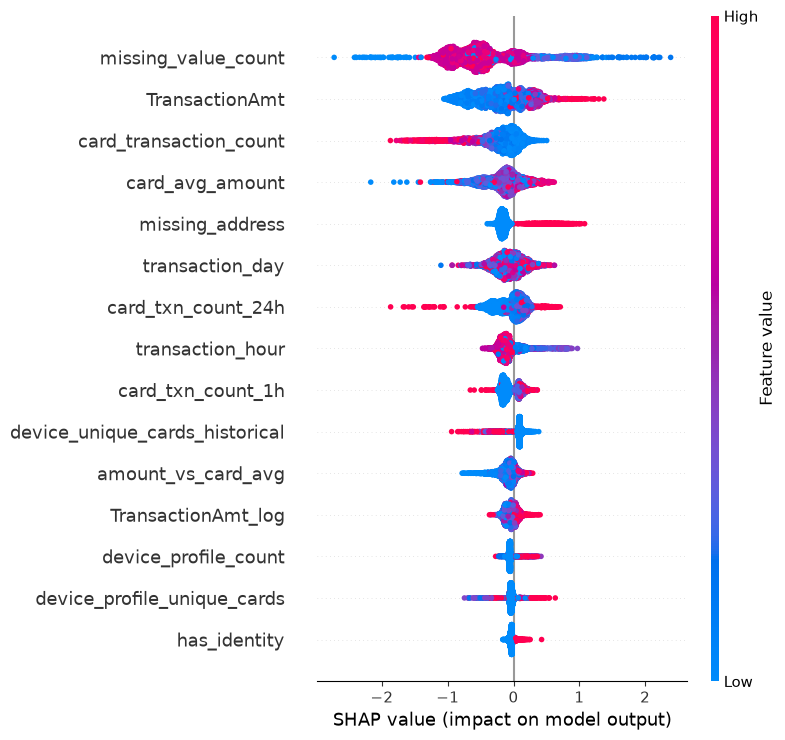

In [84]:
shap.summary_plot(
    shap_values,
    X_val_sample,
    max_display=15
)

In [85]:
sample_probabilities = xgb_model.predict_proba(
    X_val_sample
)[:, 1]

In [86]:
high_risk_idx = np.argmax(
    sample_probabilities
)

print(
    "Fraud probability:",
    sample_probabilities[high_risk_idx]
)

Fraud probability: 0.9785081


In [87]:
individual_explanation = pd.DataFrame({
    "feature": X_val_sample.columns,
    "value": X_val_sample.iloc[
        high_risk_idx
    ].values,
    "shap_value": shap_values[
        high_risk_idx
    ]
})

individual_explanation["abs_shap"] = (
    individual_explanation["shap_value"]
    .abs()
)

individual_explanation = (
    individual_explanation
    .sort_values(
        "abs_shap",
        ascending=False
    )
)

print(
    individual_explanation.head(10)
)

                           feature      value  shap_value  abs_shap
7              missing_value_count  95.000000    2.125718  2.125718
6                  missing_address   1.000000    0.824790  0.824790
9                  card_avg_amount  57.013154    0.459835  0.459835
0                   TransactionAmt  87.302000    0.350211  0.350211
20  device_unique_cards_historical  28.000000    0.102654  0.102654
13              card_txn_count_24h   1.000000   -0.068798  0.068798
12               card_txn_count_1h   0.000000   -0.067053  0.067053
10              amount_vs_card_avg   1.531261    0.053902  0.053902
15            device_profile_count  57.000000    0.052743  0.052743
4                     has_identity   1.000000    0.046012  0.046012


In [88]:
explainer = shap.TreeExplainer(xgb_model)

X_val_sample = X_val.sample(
    n=min(5000, len(X_val)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_val_sample
)

In [89]:
print(shap_importance.head(15))

                           feature  mean_abs_shap
0              missing_value_count       0.610938
1                   TransactionAmt       0.341547
2           card_transaction_count       0.278382
3                  card_avg_amount       0.240012
4                  missing_address       0.197161
5                  transaction_day       0.168335
6               card_txn_count_24h       0.167869
7                 transaction_hour       0.152370
8                card_txn_count_1h       0.125807
9   device_unique_cards_historical       0.116627
10              amount_vs_card_avg       0.105059
11              TransactionAmt_log       0.073909
12            device_profile_count       0.067280
13     device_profile_unique_cards       0.050775
14                    has_identity       0.039583


In [90]:
print(
    behavior_df.groupby("isFraud")[
        "missing_value_count"
    ].agg(
        ["mean", "median", "min", "max"]
    )
)

               mean  median  min  max
isFraud                              
0        162.204781   172.0   23  292
1        135.604691   120.0   25  268


In [91]:
print(
    behavior_df.groupby(
        pd.qcut(
            behavior_df["missing_value_count"],
            10,
            duplicates="drop"
        )
    )["isFraud"].mean()
)

missing_value_count
(22.999, 92.0]    0.092658
(92.0, 119.0]     0.062621
(119.0, 168.0]    0.047138
(168.0, 170.0]    0.015896
(170.0, 172.0]    0.020819
(172.0, 174.0]    0.009588
(174.0, 187.0]    0.035568
(187.0, 190.0]    0.020412
(190.0, 192.0]    0.013009
(192.0, 292.0]    0.024216
Name: isFraud, dtype: float64


In [92]:
print(
    pd.crosstab(
        behavior_df["has_identity"],
        behavior_df["isFraud"],
        normalize="index"
    )
)

isFraud              0         1
has_identity                    
0             0.978578  0.021422
1             0.926877  0.073123


In [93]:
print(
    behavior_df.groupby("has_identity")[
        "missing_value_count"
    ].agg(
        ["mean", "median"]
    )
)

                    mean  median
has_identity                    
0             182.484181   176.0
1             102.694444   117.0


In [94]:
print(
    behavior_df.groupby("isFraud")[
        "missing_value_count"
    ].agg(["mean", "median", "min", "max"])
)

print(
    behavior_df.groupby(
        pd.qcut(
            behavior_df["missing_value_count"],
            10,
            duplicates="drop"
        )
    )["isFraud"].mean()
)

print(
    pd.crosstab(
        behavior_df["has_identity"],
        behavior_df["isFraud"],
        normalize="index"
    )
)

print(
    behavior_df.groupby("has_identity")[
        "missing_value_count"
    ].agg(["mean", "median"])
)

               mean  median  min  max
isFraud                              
0        162.204781   172.0   23  292
1        135.604691   120.0   25  268
missing_value_count
(22.999, 92.0]    0.092658
(92.0, 119.0]     0.062621
(119.0, 168.0]    0.047138
(168.0, 170.0]    0.015896
(170.0, 172.0]    0.020819
(172.0, 174.0]    0.009588
(174.0, 187.0]    0.035568
(187.0, 190.0]    0.020412
(190.0, 192.0]    0.013009
(192.0, 292.0]    0.024216
Name: isFraud, dtype: float64
isFraud              0         1
has_identity                    
0             0.978578  0.021422
1             0.926877  0.073123
                    mean  median
has_identity                    
0             182.484181   176.0
1             102.694444   117.0


In [95]:
ABLATION_FEATURES = [
    feature
    for feature in INITIAL_FEATURES
    if feature not in [
        "missing_value_count",
        "missing_card_info",
        "missing_address",
    ]
]

print("Features:", len(ABLATION_FEATURES))
print(ABLATION_FEATURES)

Features: 18
['TransactionAmt', 'TransactionAmt_log', 'transaction_hour', 'transaction_day', 'has_identity', 'card_transaction_count', 'card_avg_amount', 'amount_vs_card_avg', 'new_card', 'card_txn_count_1h', 'card_txn_count_24h', 'has_device_info', 'device_profile_count', 'device_profile_unique_cards', 'new_device_profile', 'card_device_transaction_count', 'card_device_seen_before', 'device_unique_cards_historical']


In [96]:
X_train_ablation = behavior_df[
    ABLATION_FEATURES
].copy()

y_train_ablation = behavior_df[
    "isFraud"
].copy()

In [97]:
xgb_ablation = build_xgboost_model(
    y_train_ablation
)

xgb_ablation.fit(
    X_train_ablation,
    y_train_ablation,
    verbose=True
)

print("Ablation model trained.")

Ablation model trained.


In [98]:
X_val_ablation = validation_features[
    ABLATION_FEATURES
].copy()

y_val_ablation = validation_features[
    "isFraud"
].copy()

In [99]:
print(
    "X_train_ablation:",
    X_train_ablation.shape
)

print(
    "X_val_ablation:",
    X_val_ablation.shape
)

X_train_ablation: (413378, 18)
X_val_ablation: (88581, 18)


In [100]:
y_val_prob_ablation = (
    xgb_ablation
    .predict_proba(X_val_ablation)[:, 1]
)

In [101]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

ablation_pr_auc = average_precision_score(
    y_val_ablation,
    y_val_prob_ablation
)

ablation_roc_auc = roc_auc_score(
    y_val_ablation,
    y_val_prob_ablation
)

print(
    "Ablation PR-AUC:",
    ablation_pr_auc
)

print(
    "Ablation ROC-AUC:",
    ablation_roc_auc
)

Ablation PR-AUC: 0.13811718070040466
Ablation ROC-AUC: 0.7597967854672623


In [102]:
sample_probabilities = xgb_model.predict_proba(
    X_val
)[:, 1]

high_risk_position = np.argmax(
    sample_probabilities
)

high_risk_transaction = X_val.iloc[
    [high_risk_position]
]

In [103]:
import importlib
import src.explainability.risk_explanation as risk_module

importlib.reload(risk_module)

from src.explainability.risk_explanation import (
    RiskExplanationEngine
)


explanation_engine = RiskExplanationEngine(
    xgb_model
)

In [104]:
explanation = explanation_engine.explain(
    high_risk_transaction,
    top_k=5
)

print(explanation)

[[{'feature': 'missing_value_count', 'value': 95.0, 'shap_value': 2.1026599407196045, 'impact': 'increases_risk', 'explanation': 'The transaction contains 95 missing values; this missing-data pattern increases model risk.'}, {'feature': 'missing_address', 'value': 1.0, 'shap_value': 0.8443207740783691, 'impact': 'increases_risk', 'explanation': 'Address information is missing.'}, {'feature': 'TransactionAmt', 'value': 87.302, 'shap_value': 0.3537260890007019, 'impact': 'increases_risk', 'explanation': 'Transaction amount is 87.30; this feature increases model risk.'}, {'feature': 'card_avg_amount', 'value': 45.337777070063694, 'shap_value': 0.29721418023109436, 'impact': 'increases_risk', 'explanation': 'Historical average amount for the card is 45.34; this feature increases model risk.'}, {'feature': 'card_transaction_count', 'value': 157.0, 'shap_value': 0.2583445608615875, 'impact': 'increases_risk', 'explanation': 'The card has 157 previous transactions in the observed history.'}]]

In [105]:
from src.risk.risk import (
    classify_risk,
    make_risk_decision,
    build_risk_assessment
)

In [106]:
print(make_risk_decision(0.10))
print(make_risk_decision(0.45))
print(make_risk_decision(0.87))

{'risk_score': 0.1, 'risk_level': 'LOW', 'decision': 'APPROVE'}
{'risk_score': 0.45, 'risk_level': 'MEDIUM', 'decision': 'MONITOR'}
{'risk_score': 0.87, 'risk_level': 'HIGH', 'decision': 'REVIEW'}


In [107]:
import numpy as np

high_risk_position = np.argmax(
    y_val_prob_xgb
)

risk_probability = float(
    y_val_prob_xgb[high_risk_position]
)

print("Risk probability:", risk_probability)

Risk probability: 0.9847075939178467


In [108]:
transaction_id = int(
    validation_features.iloc[
        high_risk_position
    ]["TransactionID"]
)

print("Transaction ID:", transaction_id)

Transaction ID: 3409570


In [109]:
high_risk_transaction = X_val.iloc[
    [high_risk_position]
]

explanation = explanation_engine.explain(
    high_risk_transaction,
    top_k=5
)

In [110]:
evidence = explanation[0]

In [111]:
assessment = build_risk_assessment(
    transaction_id=transaction_id,
    probability=risk_probability,
    evidence=evidence
)

In [112]:
import pprint

pprint.pp(assessment)

{'transaction_id': 3409570,
 'risk_score': 0.9847,
 'risk_level': 'HIGH',
 'decision': 'REVIEW',
 'evidence': [{'feature': 'missing_value_count',
               'value': 95.0,
               'shap_value': 2.1026599407196045,
               'impact': 'increases_risk',
               'explanation': 'The transaction contains 95 missing values; '
                              'this missing-data pattern increases model '
                              'risk.'},
              {'feature': 'missing_address',
               'value': 1.0,
               'shap_value': 0.8443207740783691,
               'impact': 'increases_risk',
               'explanation': 'Address information is missing.'},
              {'feature': 'TransactionAmt',
               'value': 87.302,
               'shap_value': 0.3537260890007019,
               'impact': 'increases_risk',
               'explanation': 'Transaction amount is 87.30; this feature '
                              'increases model risk.'},
         

In [123]:
result = tools.get_risk_assessment(
    3409570
)

print(result)

{'transaction_id': 3409570, 'risk_score': 0.9847, 'risk_level': 'HIGH', 'decision': 'REVIEW', 'evidence': [{'feature': 'missing_value_count', 'value': 95.0, 'shap_value': 2.1026599407196045, 'impact': 'increases_risk', 'explanation': 'The transaction contains 95 missing values; this missing-data pattern increases model risk.'}, {'feature': 'missing_address', 'value': 1.0, 'shap_value': 0.8443207740783691, 'impact': 'increases_risk', 'explanation': 'Address information is missing.'}, {'feature': 'TransactionAmt', 'value': 87.302, 'shap_value': 0.3537260890007019, 'impact': 'increases_risk', 'explanation': 'Transaction amount is 87.30; this feature increases model risk.'}, {'feature': 'card_avg_amount', 'value': 45.337777070063694, 'shap_value': 0.29721418023109436, 'impact': 'increases_risk', 'explanation': 'Historical average amount for the card is 45.34; this feature increases model risk.'}, {'feature': 'card_transaction_count', 'value': 157.0, 'shap_value': 0.2583445608615875, 'impac

In [124]:
txn = tools.get_transaction(3409570)

print("TRANSACTION")
print(txn)

print("\nRISK")
print(
    tools.get_risk_assessment(3409570)
)

print("\nCARD")
print(
    tools.get_card_history(
        txn["card1"]
    )
)

print("\nDEVICE")
print(
    tools.get_device_history(
        txn["DeviceInfo"]
    )
)

TRANSACTION
{'TransactionID': 3409570, 'TransactionAmt': 87.302, 'TransactionDT': 10699419, 'card1': 12730, 'DeviceInfo': 'LG-D320 Build/KOT49I.V10a'}

RISK
{'transaction_id': 3409570, 'risk_score': 0.9847, 'risk_level': 'HIGH', 'decision': 'REVIEW', 'evidence': [{'feature': 'missing_value_count', 'value': 95.0, 'shap_value': 2.1026599407196045, 'impact': 'increases_risk', 'explanation': 'The transaction contains 95 missing values; this missing-data pattern increases model risk.'}, {'feature': 'missing_address', 'value': 1.0, 'shap_value': 0.8443207740783691, 'impact': 'increases_risk', 'explanation': 'Address information is missing.'}, {'feature': 'TransactionAmt', 'value': 87.302, 'shap_value': 0.3537260890007019, 'impact': 'increases_risk', 'explanation': 'Transaction amount is 87.30; this feature increases model risk.'}, {'feature': 'card_avg_amount', 'value': 45.337777070063694, 'shap_value': 0.29721418023109436, 'impact': 'increases_risk', 'explanation': 'Historical average amoun

In [125]:
txn = validation_features[
    validation_features["TransactionID"] == 3409570
].iloc[0]

print("Card:", txn["card1"])
print("Device:", txn["DeviceInfo"])

Card: 12730
Device: LG-D320 Build/KOT49I.V10a


In [126]:
print(
    tools.get_card_history(
        int(txn["card1"])
    )
)

{'card1': 12730, 'transaction_count': 182, 'average_amount': 44.67723626373626, 'max_amount': 249.524, 'min_amount': 3.562}


In [127]:
print(
    tools.get_device_history(
        txn["DeviceInfo"]
    )
)

{'device_info': 'LG-D320 Build/KOT49I.V10a', 'transaction_count': 68, 'unique_cards': 35}


In [115]:
investigation_history = pd.concat(
    [
        history_train,
        history_validation
    ],
    ignore_index=True
)

In [116]:
investigation_history = (
    investigation_history
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

In [117]:
print(investigation_history.shape)
print(
    investigation_history.memory_usage(
        deep=True
    ).sum() / 1024**2,
    "MB"
)

(501959, 5)
33.39766502380371 MB


In [118]:
import importlib
import src.agent.tools as tools_module
importlib.reload(tools_module)

from src.agent.tools import FraudInvestigationTools

risk_assessments = {
    3409570: assessment
}
tools = FraudInvestigationTools(
    investigation_history,
    risk_assessments
)

In [119]:
print(
    tools.get_card_history(12730)
)

{'card1': 12730, 'transaction_count': 182, 'average_amount': 44.67723626373626, 'max_amount': 249.524, 'min_amount': 3.562}


In [120]:
print(
    tools.get_device_history(
        "LG-D320 Build/KOT49I.V10a"
    )
)

{'device_info': 'LG-D320 Build/KOT49I.V10a', 'transaction_count': 68, 'unique_cards': 35}


In [121]:
txn = tools.get_transaction(3409570)

print(txn)

{'TransactionID': 3409570, 'TransactionAmt': 87.302, 'TransactionDT': 10699419, 'card1': 12730, 'DeviceInfo': 'LG-D320 Build/KOT49I.V10a'}


In [122]:
card_history = tools.get_card_history(
    txn["card1"],
    txn["TransactionDT"]
)

device_history = tools.get_device_history(
    txn["DeviceInfo"],
    txn["TransactionDT"]
)

print("CARD HISTORY")
print(card_history)

print("\nDEVICE HISTORY")
print(device_history)

CARD HISTORY
{'card1': 12730, 'transaction_count': 157, 'average_amount': 45.337777070063694, 'max_amount': 249.524, 'min_amount': 3.562}

DEVICE HISTORY
{'device_info': 'LG-D320 Build/KOT49I.V10a', 'transaction_count': 46, 'unique_cards': 27}


In [128]:
from src.agent.fraud_agent import (
    FraudInvestigationAgent
)

agent = FraudInvestigationAgent(
    tools
)

investigation = agent.investigate(
    3409570
)

In [129]:
import pprint

pprint.pp(
    investigation
)

{'transaction': {'TransactionID': 3409570,
                 'TransactionAmt': 87.302,
                 'TransactionDT': 10699419,
                 'card1': 12730,
                 'DeviceInfo': 'LG-D320 Build/KOT49I.V10a'},
 'risk_assessment': {'transaction_id': 3409570,
                     'risk_score': 0.9847,
                     'risk_level': 'HIGH',
                     'decision': 'REVIEW',
                     'evidence': [{'feature': 'missing_value_count',
                                   'value': 95.0,
                                   'shap_value': 2.1026599407196045,
                                   'impact': 'increases_risk',
                                   'explanation': 'The transaction contains 95 '
                                                  'missing values; this '
                                                  'missing-data pattern '
                                                  'increases model risk.'},
                                  {'feature

In [151]:
import importlib

import src.agent.llm as llm_module
import src.agent.fraud_agent as agent_module

importlib.reload(llm_module)
importlib.reload(agent_module)

<module 'src.agent.fraud_agent' from 'c:\\Users\\Gaurav Sehgal\\OneDrive\\Desktop\\financial_fraud_detection_agent\\src\\agent\\fraud_agent.py'>

In [152]:
from src.agent.llm import FraudLLM
from src.agent.fraud_agent import FraudInvestigationAgent

In [153]:
llm = FraudLLM()

agent = FraudInvestigationAgent(
    tools=tools,
    llm=llm
)



TypeError: FraudInvestigationAgent.__init__() missing 1 required positional argument: 'input_guardrail'

In [ ]:
report = agent.generate_report(
    3409570
)

print(report)

RISK LEVEL:
HIGH

RISK SCORE:
0.9847

DECISION:
REVIEW

KEY EVIDENCE:
- missing_value_count = 95 (high missing-data pattern, SHAP = 2.10, increases risk)  
- missing_address = 1 (address information absent, SHAP = 0.84, increases risk)  
- TransactionAmt = 87.302 (amount contributes positively to risk, SHAP = 0.35)

CARD BEHAVIOR:
- Card ID 12730 has 157 prior transactions  
- Historical average transaction amount = 45.34 (above‑average amount adds risk, SHAP = 0.30)  
- Max amount observed = 249.524, Min amount = 3.562  

DEVICE BEHAVIOR:
- Device “LG-D320 Build/KOT49I.V10a” has been used for 46 transactions  
- Associated with 27 unique cards  

INVESTIGATION SUMMARY:
The transaction (ID 3409570) shows a high proportion of missing fields (95 missing values and no address), which the model flags as risk‑increasing. The amount of $87.30 is higher than the card’s average ($45.34) and also contributes to risk. The card has a substantial transaction history (157 transactions) and the devi

In [155]:
report = agent.generate_report(
    -110
)

print(report)

Transaction not found.


In [ ]:
report = agent.generate_report(
    "LLm"
)

print(report)

In [147]:
from src.guardrails.output_guardrails import (
    OutputGuardrail
)

In [148]:
guardrail = OutputGuardrail()

validated_report = guardrail.validate(
    report,
    assessment
)

print(validated_report)

RISK LEVEL:
HIGH

RISK SCORE:
0.9847

DECISION:
REVIEW

KEY EVIDENCE:
- missing_value_count = 95 (SHAP = 2.10) – missing‑data pattern increases risk.  
- missing_address = 1 (SHAP = 0.84) – address information is absent, raising risk.  
- TransactionAmt = 87.302 (SHAP = 0.35) – amount contributes to higher risk.  

CARD BEHAVIOR:
- Card ID 12730 has 157 prior transactions.  
- Historical average transaction amount = 45.34 (SHAP = 0.30).  
- Observed amount range: min 3.56, max 249.52.

DEVICE BEHAVIOR:
- Device “LG‑D320 Build/KOT49I.V10a” has been used in 46 transactions.  
- Those transactions involve 27 distinct cards.

INVESTIGATION SUMMARY:
The transaction (ID 3409570) shows a high model‑generated risk score (0.9847) driven primarily by a large number of missing fields (95 missing values and missing address) and by the transaction amount relative to the card’s historical average. The card has a substantial transaction history (157 transactions) with an average amount roughly half o

In [149]:
bad_report = """
RISK LEVEL:
HIGH

RISK SCORE:
0.9999

DECISION:
BLOCK

This transaction is definitely fraudulent.
"""

In [150]:
guardrail.validate(
    bad_report,
    assessment
)

ValueError: Output guardrail blocked an unsupported fraud claim.